**Question 1 a**

In [20]:
import numpy as np
from pathlib import Path

def aggregate_labels(annotations):
    """
    Convert (T, C, A) to (T, C) using majority voting.
    Threshold = floor(A/2) + 1
    """
    A = annotations.shape[2]
    threshold = A // 2 + 1
    binary = (annotations > 0.5).astype(int)
    votes = binary.sum(axis=2)
    return (votes >= threshold).astype(int)

# Load dataset
dataset_path = Path('D:\JKU\Semester 3\PC\Task 4')
npz_files = list((dataset_path / 'audio_features').glob('*.npz'))

# Get class names from first file
data = np.load(npz_files[0], allow_pickle=True)
class_names = data['class_names']

# Process all files and count annotators
total_files = len(npz_files)
files_used = 0
files_excluded = 0
annotator_counts = []

for file in npz_files:
    data = np.load(file, allow_pickle=True)
    A = data['annotations'].shape[2]
    annotator_counts.append(A)
    if A >= 2:
        files_used += 1

annotator_counts = np.array(annotator_counts)

print(f"Total files: {total_files}")
print(f"Files used (≥2 annotators): {files_used}")
print()
print(f"Annotator distribution:")
print(f"  1 annotator: {(annotator_counts == 1).sum()}")
print(f"  2 annotators: {(annotator_counts == 2).sum()}")
print(f"  3 annotators: {(annotator_counts == 3).sum()}")
print(f"  4 annotators: {(annotator_counts == 4).sum()}")
print(f"  5 annotators: {(annotator_counts == 5).sum()}")

Total files: 3656
Files used (≥2 annotators): 3031

Annotator distribution:
  1 annotator: 625
  2 annotators: 1750
  3 annotators: 1235
  4 annotators: 45
  5 annotators: 1


In [21]:
import numpy as np
from pathlib import Path

def aggregate_labels(annotations):
    """Aggregate annotations of shape (T, C, A) -> (T, C) using majority voting."""
    A = annotations.shape[2]
    threshold = A // 2 + 1
    binary = (annotations > 0.5).astype(int)
    votes = binary.sum(axis=2)
    return (votes >= threshold).astype(int)

# Load all .npz files
dataset_path = Path('D:\\JKU\\Semester 3\\PC\\Task 4')
npz_files = list((dataset_path / 'audio_features').glob('*.npz'))

# Store aggregated labels and features for files with ≥2 annotators
all_X = []
all_y = []
valid_files = 0
skipped_files = 0

for file in npz_files:
    data = np.load(file, allow_pickle=True)
    annotations = data['annotations']
    A = annotations.shape[2]
    
    if A >= 2:
        valid_files += 1
        y = aggregate_labels(annotations)
        all_y.append(y)
        # Example feature collection (you can replace with your full feature extraction)
        all_X.append(data['mfcc_mean'])
    else:
        skipped_files += 1

# Combine all aggregated labels
Y_all = np.vstack(all_y) if all_y else np.array([])

print(f"Total files: {len(npz_files)}")
print(f"Valid files (≥2 annotators): {valid_files}")
print(f"Skipped files (1 annotator): {skipped_files}")
print()
print(f"Aggregated labels shape for entire dataset: {Y_all.shape}")
print(f"  T_total = {Y_all.shape[0]} time segments")
print(f"  C = {Y_all.shape[1]} classes")
print()
print("Aggregation rule applied per file based on number of annotators:")
print("  A=2 -> threshold=2 (both must agree)")
print("  A=3 -> threshold=2 (majority)")
print("  A=4 -> threshold=3 (majority)")
print("  A=5 -> threshold=3 (majority)")

Total files: 3656
Valid files (≥2 annotators): 3031
Skipped files (1 annotator): 625

Aggregated labels shape for entire dataset: (139259, 15)
  T_total = 139259 time segments
  C = 15 classes

Aggregation rule applied per file based on number of annotators:
  A=2 -> threshold=2 (both must agree)
  A=3 -> threshold=2 (majority)
  A=4 -> threshold=3 (majority)
  A=5 -> threshold=3 (majority)


**Question 1 b**

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

# ------------------------------------------------------------
# Step 1: Get list of files with ≥2 annotators
# ------------------------------------------------------------
valid_files = []
for f in npz_files:
    data = np.load(f, allow_pickle=True)
    if data['annotations'].shape[2] >= 2:
        valid_files.append(f)

print(f"Valid files (≥1 annotators): {len(valid_files)}")

# ------------------------------------------------------------
# Step 2: Split file indices (70% train, 15% val, 15% test)
# ------------------------------------------------------------
indices = np.arange(len(valid_files))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_files = [valid_files[i] for i in train_idx]
val_files   = [valid_files[i] for i in val_idx]
test_files  = [valid_files[i] for i in test_idx]

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

# ------------------------------------------------------------
# Step 3: Load aggregated labels for each split
# ------------------------------------------------------------
def load_aggregated_labels(file_list):
    y_list = []
    for f in file_list:
        data = np.load(f, allow_pickle=True)
        y = aggregate_labels(data['annotations'])   # from 1a
        y_list.append(y)
    return np.vstack(y_list)

y_train = load_aggregated_labels(train_files)
y_val   = load_aggregated_labels(val_files)
y_test  = load_aggregated_labels(test_files)

# ------------------------------------------------------------
# Step 4: Compute class frequencies (percentage)
# ------------------------------------------------------------
train_freq = y_train.mean(axis=0) * 100
val_freq   = y_val.mean(axis=0) * 100
test_freq  = y_test.mean(axis=0) * 100

# Get class names from first valid file
class_names = np.load(valid_files[0], allow_pickle=True)['class_names']

print("\n=== Class distribution across splits (% of time segments) ===")
print(f"{'Class':<30} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 56)
for i, name in enumerate(class_names):
    print(f"{name:<30} {train_freq[i]:>7.2f}% {val_freq[i]:>7.2f}% {test_freq[i]:>7.2f}%")

Valid files (≥1 annotators): 3031
Train files: 2121
Val files:   455
Test files:  455

=== Class distribution across splits (% of time segments) ===
Class                             Train      Val     Test
--------------------------------------------------------
bell_ringing                      1.14%    1.32%    1.54%
coffee_machine                    3.50%    4.36%    3.70%
cutlery_dishes                    5.49%    6.18%    6.10%
door_open_close                   3.30%    3.33%    3.21%
footsteps                        11.55%   11.35%   11.09%
keyboard_typing                   9.33%    9.21%    7.85%
keychain                          4.48%    4.02%    4.99%
light_switch                      0.26%    0.26%    0.26%
microwave                         6.82%    6.85%    7.28%
phone_ringing                     5.79%    7.00%    6.05%
running_water                    11.96%   11.84%   15.31%
toilet_flushing                   3.17%    2.54%    2.62%
vacuum_cleaner                    6.36% 

**Question 1 c**

In [23]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Define all 55 feature names (same as before)
# ------------------------------------------------------------
FEATURE_NAMES = [
    'zcr_mean',
    'mfcc_mean',
    'mfcc_d_mean',
    'mfcc_d2_mean',
    'flux_mean',
    'flatness_mean',
    'centroid_mean',
    'bandwidth_mean',
    'contrast_mean', 
    'rolloff_low_mean',
    'rolloff_high_mean',
    'energy_mean',
    'power_mean'
]

# ------------------------------------------------------------
# Function to load features from a list of files (all 55 features)
# ------------------------------------------------------------
def load_features(file_list):
    X_list = []
    for f in file_list:
        data = np.load(f, allow_pickle=True)
        feats = []
        for key in FEATURE_NAMES:
            if key in data:
                feat = data[key]
                # If feature is multi-dimensional (e.g., melspect_mean: (T,128)), flatten
                if feat.ndim > 1:
                    feats.append(feat.reshape(feat.shape[0], -1))
                else:
                    feats.append(feat.reshape(-1, 1))
            else:
                # Fallback: should not happen, but handle gracefully
                T = data['zcr_mean'].shape[0] if 'zcr_mean' in data else 100
                feats.append(np.zeros((T, 1)))
        X_list.append(np.hstack(feats))
    return np.vstack(X_list)

# ------------------------------------------------------------
# Load features for each split (using same file splits from 1b)
# ------------------------------------------------------------
X_train = load_features(train_files)
X_val   = load_features(val_files)
X_test  = load_features(test_files)

print("Shapes before normalization:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print()

# ------------------------------------------------------------
# Normalize: fit on train only
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm   = scaler.transform(X_val)
X_test_norm  = scaler.transform(X_test)

print("Before normalization:")
print(f"  Train: mean={X_train.mean():.6f}, std={X_train.std():.6f}")
print(f"  Val:   mean={X_val.mean():.6f},   std={X_val.std():.6f}")
print(f"  Test:  mean={X_test.mean():.6f},  std={X_test.std():.6f}")
print()
print("After normalization (fitted on train):")
print(f"  Train: mean={X_train_norm.mean():.6f}, std={X_train_norm.std():.6f}")
print(f"  Val:   mean={X_val_norm.mean():.6f},   std={X_val_norm.std():.6f}")
print(f"  Test:  mean={X_test_norm.mean():.6f},  std={X_test_norm.std():.6f}")

Shapes before normalization:
  X_train: (97391, 112)
  X_val:   (20976, 112)
  X_test:  (20892, 112)

Before normalization:
  Train: mean=93.711535, std=600.512289
  Val:   mean=93.663866,   std=600.374655
  Test:  mean=94.794360,  std=606.088581

After normalization (fitted on train):
  Train: mean=0.000000, std=1.000000
  Val:   mean=0.002920,   std=1.003402
  Test:  mean=-0.003710,  std=1.007395


In [24]:
# Leakage check: ensure file sets are disjoint
train_set = set(train_files)
val_set   = set(val_files)
test_set  = set(test_files)

print("File split overlap check:")
print(f"Train ∩ Val = {len(train_set & val_set)} (should be 0)")
print(f"Train ∩ Test = {len(train_set & test_set)} (should be 0)")
print(f"Val ∩ Test   = {len(val_set & test_set)} (should be 0)")

if len(train_set & val_set) == 0 and len(train_set & test_set) == 0 and len(val_set & test_set) == 0:
    print("✅ No leakage: all splits contain disjoint files.")
else:
    print("❌ Leakage detected: same file appears in multiple splits.")

File split overlap check:
Train ∩ Val = 0 (should be 0)
Train ∩ Test = 0 (should be 0)
Val ∩ Test   = 0 (should be 0)
✅ No leakage: all splits contain disjoint files.


**Question 2 a**

In [25]:
import numpy as np

# Assume y_train is already loaded from previous steps (shape: (n_samples, 15))

# 1. Compute class frequencies (percentage of time segments containing each class)
class_freq = y_train.mean(axis=0) * 100
min_freq = class_freq.min()
max_freq = class_freq.max()
imbalance_ratio = max_freq / min_freq

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS (Training Set)")
print("=" * 60)
print(f"{'Class':<30} {'Frequency (%)':>15}")
print("-" * 45)
for i, name in enumerate(class_names):
    print(f"{name:<30} {class_freq[i]:>14.2f}%")
print("-" * 45)
print(f"Most frequent class: {class_names[np.argmax(class_freq)]} ({max_freq:.2f}%)")
print(f"Least frequent class: {class_names[np.argmin(class_freq)]} ({min_freq:.2f}%)")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print()

# 2. Simulate a dummy classifier that always predicts "absent" (all zeros)
# to show why plain accuracy is misleading
dummy_pred = np.zeros_like(y_train)
accuracy = (dummy_pred == y_train).mean()
# Balanced accuracy for dummy: per‑class recall = 0 for classes that appear, but macro average will be 0.5? Actually balanced accuracy = average recall per class.
# Compute macro recall for dummy
per_class_recall = []
for i in range(y_train.shape[1]):
    tp = np.sum((y_train[:, i] == 1) & (dummy_pred[:, i] == 1))
    fn = np.sum((y_train[:, i] == 1) & (dummy_pred[:, i] == 0))
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    per_class_recall.append(recall)
macro_recall = np.mean(per_class_recall)
print("Dummy classifier (always predicts 0):")
print(f"  Plain accuracy: {accuracy:.4f} (looks good, but model learns nothing)")
print(f"  Macro‑averaged recall (Balanced Accuracy): {macro_recall:.4f} (reveals failure)")
print(f"high accuracy ({accuracy:.2%}) while detecting no positive events.")

CLASS IMBALANCE ANALYSIS (Training Set)
Class                            Frequency (%)
---------------------------------------------
bell_ringing                             1.14%
coffee_machine                           3.50%
cutlery_dishes                           5.49%
door_open_close                          3.30%
footsteps                               11.55%
keyboard_typing                          9.33%
keychain                                 4.48%
light_switch                             0.26%
microwave                                6.82%
phone_ringing                            5.79%
running_water                           11.96%
toilet_flushing                          3.17%
vacuum_cleaner                           6.36%
wardrobe_drawer_open_close               1.88%
window_open_close                        1.18%
---------------------------------------------
Most frequent class: running_water (11.96%)
Least frequent class: light_switch (0.26%)
Imbalance ratio (max/min): 46

**Question 2 b**

In [26]:
# Correct evaluation metrics for multi-label classification
import numpy as np

def balanced_accuracy_multilabel(y_true, y_pred):
    """
    Macro-averaged balanced accuracy.
    For each class: (TPR + TNR) / 2, then average across classes.
    """
    scores = []
    for i in range(y_true.shape[1]):
        tn = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 0))
        fp = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
        fn = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
        tp = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        scores.append((tpr + tnr) / 2)
    return np.mean(scores)

def macro_f1_score(y_true, y_pred):
    """Macro-averaged F1 score across classes."""
    f1s = []
    for i in range(y_true.shape[1]):
        tp = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
        fp = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
        fn = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        f1s.append(f1)
    return np.mean(f1s)

In [27]:
import numpy as np

# Assume y_train, y_val are already loaded (binary labels)
# y_train shape: (n_train, 15)
# y_val shape:   (n_val, 15)

# ------------------------------------------------------------
# Baseline 1: Random prediction using empirical class frequencies
# ------------------------------------------------------------
train_freq = y_train.mean(axis=0)  # probability of each class in training set

np.random.seed(42)
n_val = y_val.shape[0]
y_pred_random = (np.random.rand(n_val, 15) < train_freq).astype(int)

# ------------------------------------------------------------
# Baseline 2: Always predict 0 (all negative)
# ------------------------------------------------------------
y_pred_zero = np.zeros_like(y_val)

# ------------------------------------------------------------
# Compute performances using corrected metrics
# ------------------------------------------------------------
random_bal_acc = balanced_accuracy_multilabel(y_val, y_pred_random)
zero_bal_acc   = balanced_accuracy_multilabel(y_val, y_pred_zero)

random_f1 = macro_f1_score(y_val, y_pred_random)
zero_f1   = macro_f1_score(y_val, y_pred_zero)

print("Baseline Performance on Validation Set:")
print(f"  Random baseline:      Balanced Accuracy = {random_bal_acc:.4f}, Macro F1 = {random_f1:.4f}")
print(f"  All‑zero baseline:    Balanced Accuracy = {zero_bal_acc:.4f}, Macro F1 = {zero_f1:.4f}")
print()
print("Note: Balanced accuracy = average of (TPR + TNR)/2 per class.")

Baseline Performance on Validation Set:
  Random baseline:      Balanced Accuracy = 0.4987, Macro F1 = 0.0495
  All‑zero baseline:    Balanced Accuracy = 0.5000, Macro F1 = 0.0000

Note: Balanced accuracy = average of (TPR + TNR)/2 per class.


Decision Tree Hyperparameter Tuning
depth=20, split=10, criterion=gini   -> macro F1 = 0.2870

Best Decision Tree: {'max_depth': 20, 'min_samples_split': 10, 'criterion': 'gini'} | validation macro F1 = 0.2870



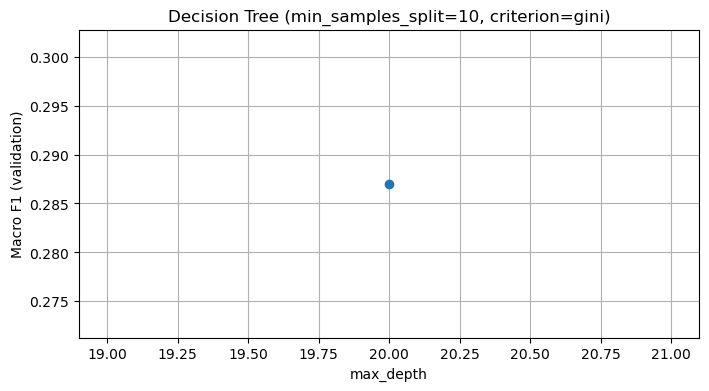

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier

# # ------------------------------------------------------------
# # Evaluation metric: macro‑averaged F1 (balanced precision/recall)
# # ------------------------------------------------------------
# def macro_f1_score(y_true, y_pred):
#     f1s = []
#     for i in range(y_true.shape[1]):
#         tp = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
#         fp = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
#         fn = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
#         f1s.append(f1)
#     return np.mean(f1s)

# # ============================================================
# # 1. Decision Tree (model class: Tree)
# # ============================================================
# print("=" * 60)
# print("Decision Tree Hyperparameter Tuning")
# print("=" * 60)

# dt_params = {
#     'max_depth': [20],
#     'min_samples_split': [5],
#     'criterion': ['gini']
# }

# best_dt_score = 0
# best_dt_params = None
# dt_results = []  # store (depth, split, criterion, score)

# for d in dt_params['max_depth']:
#     for s in dt_params['min_samples_split']:
#         for c in dt_params['criterion']:
#             clf = MultiOutputClassifier(
#                 DecisionTreeClassifier(max_depth=d, min_samples_split=s, criterion=c, random_state=42)
#             )
#             clf.fit(X_train_norm, y_train)
#             y_pred = clf.predict(X_val_norm)
#             score = macro_f1_score(y_val, y_pred)
#             dt_results.append((d, s, c, score))
#             if score > best_dt_score:
#                 best_dt_score = score
#                 best_dt_params = {'max_depth': d, 'min_samples_split': s, 'criterion': c}
#             print(f"depth={d}, split={s}, criterion={c:6} -> macro F1 = {score:.4f}")

# print(f"\nBest Decision Tree: {best_dt_params} | validation macro F1 = {best_dt_score:.4f}\n")

# # ------------------------------------------------------------
# # Plot Decision Tree: effect of max_depth (fix best split & criterion)
# # ------------------------------------------------------------
# best_split = best_dt_params['min_samples_split']
# best_crit = best_dt_params['criterion']
# filtered = [(d, sc) for (d, s, c, sc) in dt_results if s == best_split and c == best_crit]
# depths = [d for d, _ in filtered]
# scores = [sc for _, sc in filtered]

# plt.figure(figsize=(8, 4))
# plt.plot(depths, scores, marker='o')
# plt.xlabel('max_depth')
# plt.ylabel('Macro F1 (validation)')
# plt.title(f'Decision Tree (min_samples_split={best_split}, criterion={best_crit})')
# plt.grid(True)
# plt.savefig('dt_tuning.png')
# plt.show()

# ============================================================
# 2. K-Nearest Neighbors (model class: Nearest Neighbor)
# ============================================================
print("=" * 60)
print("K-Nearest Neighbors Hyperparameter Tuning")
print("=" * 60)

knn_params = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]          # 1 = Manhattan, 2 = Euclidean
}

best_knn_score = 0
best_knn_params = None
knn_results = []  # store (k, weights, p, score)

for k in knn_params['n_neighbors']:
    for w in knn_params['weights']:
        for p in knn_params['p']:
            clf = MultiOutputClassifier(
                KNeighborsClassifier(n_neighbors=k, weights=w, p=p, n_jobs=-1)
            )
            clf.fit(X_train_norm, y_train)
            y_pred = clf.predict(X_val_norm)
            score = macro_f1_score(y_val, y_pred)
            knn_results.append((k, w, p, score))
            if score > best_knn_score:
                best_knn_score = score
                best_knn_params = {'n_neighbors': k, 'weights': w, 'p': p}
            print(f"k={k:2}, weights={w:8}, p={p} -> macro F1 = {score:.4f}")

print(f"\nBest KNN: {best_knn_params} | validation macro F1 = {best_knn_score:.4f}\n")

# ------------------------------------------------------------
# Plot KNN: effect of n_neighbors for different (weights, p)
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
for w in ['uniform', 'distance']:
    for p in [1, 2]:
        vals = [(k, sc) for (k, w2, p2, sc) in knn_results if w2 == w and p2 == p]
        if vals:
            k_vals = [v[0] for v in vals]
            scores = [v[1] for v in vals]
            plt.plot(k_vals, scores, marker='o', label=f'weights={w}, p={p}')
plt.xlabel('n_neighbors')
plt.ylabel('Macro F1 (validation)')
plt.title('K-Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.savefig('knn_tuning.png')
plt.show()

# ============================================================
# Final note
# ============================================================
print("Hyperparameter tuning completed. Use the best models for final test evaluation (3b).")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier

# # ------------------------------------------------------------
# # Evaluation metric: macro‑averaged F1 (balanced precision/recall)
# # ------------------------------------------------------------
# def macro_f1_score(y_true, y_pred):
#     f1s = []
#     for i in range(y_true.shape[1]):
#         tp = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
#         fp = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
#         fn = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
#         f1s.append(f1)
#     return np.mean(f1s)

# # ============================================================
# # 1. Decision Tree (model class: Tree)
# # ============================================================
# print("=" * 60)
# print("Decision Tree Hyperparameter Tuning")
# print("=" * 60)

# dt_params = {
#     'max_depth': [20],
#     'min_samples_split': [5],
#     'criterion': ['gini']
# }

# best_dt_score = 0
# best_dt_params = None
# dt_results = []  # store (depth, split, criterion, score)

# for d in dt_params['max_depth']:
#     for s in dt_params['min_samples_split']:
#         for c in dt_params['criterion']:
#             clf = MultiOutputClassifier(
#                 DecisionTreeClassifier(max_depth=d, min_samples_split=s, criterion=c, random_state=42)
#             )
#             clf.fit(X_train_norm, y_train)
#             y_pred = clf.predict(X_val_norm)
#             score = macro_f1_score(y_val, y_pred)
#             dt_results.append((d, s, c, score))
#             if score > best_dt_score:
#                 best_dt_score = score
#                 best_dt_params = {'max_depth': d, 'min_samples_split': s, 'criterion': c}
#             print(f"depth={d}, split={s}, criterion={c:6} -> macro F1 = {score:.4f}")

# print(f"\nBest Decision Tree: {best_dt_params} | validation macro F1 = {best_dt_score:.4f}\n")

# # ------------------------------------------------------------
# # Plot Decision Tree: effect of max_depth (fix best split & criterion)
# # ------------------------------------------------------------
# best_split = best_dt_params['min_samples_split']
# best_crit = best_dt_params['criterion']
# filtered = [(d, sc) for (d, s, c, sc) in dt_results if s == best_split and c == best_crit]
# depths = [d for d, _ in filtered]
# scores = [sc for _, sc in filtered]

# plt.figure(figsize=(8, 4))
# plt.plot(depths, scores, marker='o')
# plt.xlabel('max_depth')
# plt.ylabel('Macro F1 (validation)')
# plt.title(f'Decision Tree (min_samples_split={best_split}, criterion={best_crit})')
# plt.grid(True)
# plt.savefig('dt_tuning.png')
# plt.show()

# ============================================================
# 2. K-Nearest Neighbors (model class: Nearest Neighbor)
# ============================================================
print("=" * 60)
print("K-Nearest Neighbors Hyperparameter Tuning")
print("=" * 60)

knn_params = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]          # 1 = Manhattan, 2 = Euclidean
}

best_knn_score = 0
best_knn_params = None
knn_results = []  # store (k, weights, p, score)

for k in knn_params['n_neighbors']:
    for w in knn_params['weights']:
        for p in knn_params['p']:
            clf = MultiOutputClassifier(
                KNeighborsClassifier(n_neighbors=k, weights=w, p=p, n_jobs=-1)
            )
            clf.fit(X_train_norm, y_train)
            y_pred = clf.predict(X_val_norm)
            score = macro_f1_score(y_val, y_pred)
            knn_results.append((k, w, p, score))
            if score > best_knn_score:
                best_knn_score = score
                best_knn_params = {'n_neighbors': k, 'weights': w, 'p': p}
            print(f"k={k:2}, weights={w:8}, p={p} -> macro F1 = {score:.4f}")

print(f"\nBest KNN: {best_knn_params} | validation macro F1 = {best_knn_score:.4f}\n")

# ------------------------------------------------------------
# Plot KNN: effect of n_neighbors for different (weights, p)
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
for w in ['uniform', 'distance']:
    for p in [1, 2]:
        vals = [(k, sc) for (k, w2, p2, sc) in knn_results if w2 == w and p2 == p]
        if vals:
            k_vals = [v[0] for v in vals]
            scores = [v[1] for v in vals]
            plt.plot(k_vals, scores, marker='o', label=f'weights={w}, p={p}')
plt.xlabel('n_neighbors')
plt.ylabel('Macro F1 (validation)')
plt.title('K-Nearest Neighbors')
plt.legend()
plt.grid(True)
plt.savefig('knn_tuning.png')
plt.show()

# ============================================================
# Final note
# ============================================================
print("Hyperparameter tuning completed. Use the best models for final test evaluation (3b).")

K-Nearest Neighbors Hyperparameter Tuning
k= 1, weights=uniform , p=1 -> macro F1 = 0.2652
k= 1, weights=uniform , p=2 -> macro F1 = 0.2588
k= 1, weights=distance, p=1 -> macro F1 = 0.2652
k= 1, weights=distance, p=2 -> macro F1 = 0.2588
k= 3, weights=uniform , p=1 -> macro F1 = 0.2377
k= 3, weights=uniform , p=2 -> macro F1 = 0.2367
k= 3, weights=distance, p=1 -> macro F1 = 0.2377
k= 3, weights=distance, p=2 -> macro F1 = 0.2367
k= 5, weights=uniform , p=1 -> macro F1 = 0.2236
k= 5, weights=uniform , p=2 -> macro F1 = 0.2191
k= 5, weights=distance, p=1 -> macro F1 = 0.2236
k= 5, weights=distance, p=2 -> macro F1 = 0.2191
k= 7, weights=uniform , p=1 -> macro F1 = 0.2089
k= 7, weights=uniform , p=2 -> macro F1 = 0.2054
k= 7, weights=distance, p=1 -> macro F1 = 0.2089
k= 7, weights=distance, p=2 -> macro F1 = 0.2054
k= 9, weights=uniform , p=1 -> macro F1 = 0.1970
k= 9, weights=uniform , p=2 -> macro F1 = 0.1989
k= 9, weights=distance, p=1 -> macro F1 = 0.1970
k= 9, weights=distance, p=2